# Westeros as a Social Network
### An explainer notebook for 02467 Computational Social Science, Spring 2026

*Companion to the project website. The website tells the story; this notebook documents how we got there (the data, the methods, the choices, and the limits).*


## 1. Motivation

### What is the dataset?
Every character page on [A Wiki of Ice and Fire](https://awoiaf.westeros.org), the canonical fan-curated reference for George R. R. Martin's *A Song of Ice and Fire*. We scraped:

- A roster of **3,689 characters** with infobox metadata (parents, spouse, allegiance, etc.)
- The full narrative **biography** for each (≈ 9 MB of prose total)
- All **quotes** attributed to each character (≈ 4,600 individual quotes)
- A character-to-character **affiliation graph** derived from in-article links

### Why this dataset?
*A Song of Ice and Fire* is famous for its dense web of allegiances, betrayals, and family rivalries. Two structures jump out:

1. A **social network** - who interacts with whom, mediated through shared house, shared region, shared cause
2. A **text corpus** - distinctive vocabularies per house and per main character, ripe for NLP

Combining the two is exactly the computational social science setup: ground-truth labels (house, region) on graph nodes that *also* carry rich text. Few real-world social datasets give you both at this scale and quality, with the bonus that no privacy concerns apply (every subject is fictional).

### Central question
**Can the social structure of a fictional world be recovered from co-affiliation alone, and where does the recovery break down?**

We will show that:
- Louvain community detection on the co-affiliation graph **rediscovers Westerosi timelines/storylines** with high accuracy.
- It rediscovers **houses** only moderately well, because dynastic houses span centuries and they are not as polarized as one might expect.
- A per-house text analysis surfaces **distinctive vocabularies** that are independently informative.
- An LLM-scored friend/enemy overlay reveals one **asymmetric** structure that the symmetric graph cannot.

### Goal for the end-user
A reader of the website should come away with two intuitions: (1) the *storyline* hypothesis explains the Westerosi social graph better than the *house* hypothesis, and (2) text and network signals reinforce each other but disagree about edge cases in ways that are themselves interesting.

In [18]:
# Imports used throughout the notebook
# Imports should stay limited to what the notebook actually uses.

import math
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

import networkx as nx
import matplotlib.colors as mcolors
import seaborn as sns
from collections import defaultdict
import random
from tqdm import tqdm
import requests
import os
from pathlib import Path

from bs4 import BeautifulSoup
import re
from urllib.parse import quote, unquote
from concurrent.futures import ThreadPoolExecutor

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Shared plot style, aligned with the website and final figure notebooks.
PLOT_BG = '#0c0d11'
PLOT_PANEL = '#11131a'
PLOT_INK = '#ece5d1'
PLOT_SOFT = '#c8c1ad'
PLOT_MUTED = '#8c8674'
PLOT_GRID = '#2e2f38'
PLOT_GOLD = '#c9a661'
PLOT_GOLD_BRIGHT = '#e3c382'
PLOT_CRIMSON = '#b3262d'
PLOT_BLUE = '#5B8DB8'
PLOT_GREEN = '#3f8d5a'

WEBSITE_FIGURES = Path('website/figures')
NETWORK_ANALYSIS_FIGURES = WEBSITE_FIGURES / 'network_analysis'
NETWORK_ANALYSIS_FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': PLOT_BG,
    'axes.facecolor': PLOT_PANEL,
    'axes.edgecolor': PLOT_GRID,
    'axes.labelcolor': PLOT_INK,
    'xtick.color': PLOT_SOFT,
    'ytick.color': PLOT_SOFT,
    'text.color': PLOT_INK,
    'axes.titlecolor': PLOT_GOLD_BRIGHT,
    'grid.color': PLOT_GRID,
    'legend.facecolor': PLOT_PANEL,
    'legend.edgecolor': PLOT_GRID,
    'legend.labelcolor': PLOT_INK,
})

def style_axis(ax, grid=True):
    ax.set_facecolor(PLOT_PANEL)
    for spine in ax.spines.values():
        spine.set_color(PLOT_GRID)
    ax.tick_params(colors=PLOT_SOFT)
    if grid:
        ax.grid(True, color=PLOT_GRID, alpha=0.45, ls=':', lw=0.8)
    return ax

## 2. Basic statistics

### Data collection
We hit each character's wiki page directly (the wiki has no formal API) with a browser User-Agent. The wiki blocks generic bot strings. Parallelized at 8 workers; total scrape time ≈ 10 minutes. All scraped pages are public, contain no PII (every subject is fictional), and we cite the wiki as the data source. We never write back to the wiki.

Four scrapers run independently:
1. **List scraper** → `characters.csv` (3,689 name + slug pairs from `List_of_characters`)
2. **Enrichment scraper** → `csvs/characters_enriched_v3.csv` (parent, spouse, allegiance, affiliated)
3. **Biography scraper** → `csvs/characters_bio.csv`
4. **Quote scraper** → `csvs/characters_quotes.csv`

### Data cleaning: the Family-section problem
The first version of the enrichment scraper (`scrape_characters.ipynb`) walked the entire article body and collected every internal `/index.php/` link as a co-affiliation edge. That is the **naïve maximal extraction**, and it created edges between e.g. Daenerys Targaryen and Aegon I, characters separated by 296 in-universe years who never met. The cause: every Targaryen's `Family` section lists every ancestor and descendant, and the parser made no distinction between *Family* and *History*/*Recent Events* sections.

**v2 fix:** `scrape_characters_v2.ipynb` builds a set of every DOM node inside any `Family` h2 and skips links inside that set. We tested first by surveying every section heading across all 3,689 pages: `Family` appears on 1,423 pages (38.7%), with `Ancestors` and `Descendants` as the dominant h3 subsections inside it. The v2 cut measurably shrinks each character's affiliated list, the drop is dominated by dynastic characters (Targaryens, Lannisters, Starks) whose Family sections were heaviest.

**v3 fix:** realizing that "Demon of Darry" (a character with a small biography) was being considered one of the most connected characters, we quickly understood that something was wrong. The scraper was collecting character links from below the `References` heading. Tables that explained lore only tangentially related to the character page were being hit, further muddying the data. To remove the contamination, only relevant section titles were considered for scraping, while everything outside them was ignored.

## Code Explanation: Data Collection & Preprocessing

We scrape four datasets from A Wiki of Ice and Fire (`awoiaf.westeros.org`) using standard HTTP GET requests with a browser User-Agent, the wiki blocks generic bot strings. Parallelized at 8 workers; total scrape time ≈ 10 minutes.

| File | Contents |
|------|----------|
| `characters.csv` | name + ID (slug) for every character |
| `csvs/characters_enriched_v3.csv` | structured metadata per character |
| `csvs/characters_bio.csv` | full narrative biography per character |
| `csvs/characters_quotes.csv` | all quotes attributed to each character |

Every character has a unique URL slug (e.g. `Jon_Snow`, `Aegon_Frey_(son_of_Aenys)`) used as a stable ID throughout. All inter-character references are stored as slugs rather than display names to avoid ambiguity.

---

### Enrichment scraper - `csvs/characters_enriched_v3.csv`

Two tasks per page: `parse_infobox` reads the sidebar table for structured fields (parents, spouse, allegiance, etc.), and `parse_affiliated_v3` collects co-affiliation edges from internal character links. The affiliated parser went through three versions:

- **v1:** collected all links on the page - created spurious edges between characters separated by centuries via Family section ancestor lists.
- **v2:** excluded the Family section - succession tables and navboxes below References were still polluting the data. "Demon of Darry" appeared as one of the most connected characters as a result.
- **v3:** allowlist only - links are collected exclusively from `History` and `Recent Events` sections. Everything else is ignored.

After scraping, all slugs are validated against the known character ID set and non-character entries are dropped.

---

### Biography scraper - `csvs/characters_bio.csv`

Extracts narrative prose from History/Biography sections. Every character name that appears as a hyperlink in the text is replaced by the link's target slug. Plain unlinked text is kept verbatim. This resolves disambiguation naturally, since the wiki editors already link to the correct page (e.g. the two `Aegon Frey` characters each link to different slugs).

---

### Quotes scraper - `csvs/characters_quotes.csv`

Quotes live on the main character page under headings like *Quotes by Arya*. We ignore the headings and grab every `<blockquote class="templatequote">` directly. The `templatequotetext` div gives the quote; the `templatequotecite` div gives the attribution line, from which we extract `speaker_id` (first character link) and `recipient_id` (second character link). One row per quote.

In [13]:
BASE   = 'https://awoiaf.westeros.org'
PREFIX = '/index.php/'

headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
}

session = requests.Session()
session.headers.update(headers)


def slug_to_url(slug):
    return BASE + PREFIX + quote(slug, safe="_/(),'")


def href_to_slug(href):
    """Return the URL-decoded slug for an internal wiki link, or None."""
    if not href.startswith(PREFIX):
        return None
    if 'redlink=1' in href or 'action=' in href:
        return None
    slug = href[len(PREFIX):].split('#', 1)[0]
    if not slug or slug.startswith('Special:'):
        return None
    return unquote(slug)


In [14]:
CHARACTERS_CSV = 'csvs/characters.csv' # Update the path if necessary

if os.path.exists(CHARACTERS_CSV):
    char_df = pd.read_csv(CHARACTERS_CSV)
    print(f'Loaded {len(char_df)} characters from {CHARACTERS_CSV}')
else:
    # Scrape the list page if the CSV isn't cached yet
    list_page = session.get(BASE + PREFIX + 'List_of_characters', timeout=20)
    soup = BeautifulSoup(list_page.content, 'html.parser')
    content = soup.find('div', class_='mw-parser-output')
    characters_raw, seen_ids = [], set()
    for li in content.find_all('li'):
        a = li.find('a')
        if not a:
            continue
        href = a.get('href', '')
        if not href.startswith(PREFIX) or 'redlink=1' in href:
            continue
        slug = unquote(href[len(PREFIX):].split('#', 1)[0])
        if not slug or slug.startswith('Special:') or slug in seen_ids:
            continue
        seen_ids.add(slug)
        name = a.get_text(strip=True)
        if name:
            characters_raw.append({'name': name, 'ID': slug})
    char_df = pd.DataFrame(characters_raw, columns=['name', 'ID'])
    char_df.to_csv(CHARACTERS_CSV, index=False)
    print(f'Scraped and saved {len(char_df)} characters')

characters   = char_df.to_dict('records')
character_ids = set(row['ID'] for row in characters)
print(f'{len(characters)} characters, {len(character_ids)} unique IDs')


Loaded 3690 characters from csvs/characters.csv
3690 characters, 3690 unique IDs


In [ ]:
# ── Infobox field mapping ───────────────────────────────────────────────────
INFOBOX_LABELS = {
    'Father': 'father',  'Fathers': 'father',
    'Mother': 'mother',  'Mothers': 'mother',
    'Spouse': 'spouse',  'Spouses': 'spouse',
    'Lover':  'lover',   'Lovers':  'lover',  'Paramour': 'lover',
    'Issue':  'issue',   'Issues':  'issue',
    'Allegiance': 'allegiance', 'Allegiances': 'allegiance',
}


def cell_links_or_text(td):
    """Return semicolon-joined slugs from a table cell, or plain text if no links."""
    slugs, seen = [], set()
    for a in td.find_all('a'):
        slug = href_to_slug(a.get('href', ''))
        if slug and slug not in seen:
            seen.add(slug)
            slugs.append(slug)
    if slugs:
        return ';'.join(slugs)
    text = td.get_text(' ', strip=True)
    return text if text else ''


def parse_infobox(soup):
    """Extract structured fields from the character infobox."""
    data = {col: '' for col in INFOBOX_LABELS.values()}
    infobox = soup.find('table', class_='infobox')
    if infobox is None:
        return data
    for row in infobox.find_all('tr'):
        th, td = row.find('th'), row.find('td')
        if not th or not td:
            continue
        col = INFOBOX_LABELS.get(th.get_text(strip=True).rstrip(':'))
        if col and data[col] == '':
            data[col] = cell_links_or_text(td)
    return data


# ── v3 affiliated parser: History/Recent Events sections only ────────────────
INCLUDED_H2_SECTIONS = {'history', 'recent events', 'recent event', 'histoy'}  # 'histoy' = wiki typo


def parse_affiliated_v3(soup, self_slug):
    content = soup.find('div', class_='mw-parser-output')
    if content is None:
        return ''
    included = set()
    for h in content.find_all('h2'):
        span = h.find('span', class_='mw-headline')
        if not span or span.get_text(strip=True).lower() not in INCLUDED_H2_SECTIONS:
            continue
        included.add(id(h))
        for d in h.find_all(True):
            included.add(id(d))
        for sib in h.find_next_siblings():
            if sib.name == 'h2':
                break
            included.add(id(sib))
            for d in sib.find_all(True):
                included.add(id(d))
    slugs, seen = [], set()
    for a in content.find_all('a'):
        if id(a) not in included:
            continue
        slug = href_to_slug(a.get('href', ''))
        if slug and slug != self_slug and slug not in seen:
            seen.add(slug)
            slugs.append(slug)
    return ';'.join(slugs)


# ── per-character scrape ─────────────────────────────────────────────────────
EMPTY = {k: '' for k in ['father', 'mother', 'spouse', 'lover', 'issue', 'allegiance', 'affiliated']}


def scrape_character(row):
    name, slug = row['name'], row['ID']
    try:
        resp = session.get(slug_to_url(slug), timeout=20)
    except requests.RequestException as e:
        return {'name': name, 'ID': slug, **EMPTY}
    if resp.status_code != 200:
        return {'name': name, 'ID': slug, **EMPTY}
    soup = BeautifulSoup(resp.content, 'html.parser')
    info = parse_infobox(soup)
    return {'name': name, 'ID': slug, **info,
            'affiliated': parse_affiliated_v3(soup, slug)}


# ── run ──────────────────────────────────────────────────────────────────────
COLUMNS_ENR = ['name', 'ID', 'father', 'mother', 'spouse', 'lover', 'issue', 'allegiance', 'affiliated']
OUT_ENR = 'csvs/characters_enriched_v3.csv'

rows = []
with ThreadPoolExecutor(max_workers=8) as executor:
    for i, row in enumerate(executor.map(scrape_character, characters), 1):
        rows.append(row)
        if i % 100 == 0:
            print(f'  {i}/{len(characters)}')
            pd.DataFrame(rows, columns=COLUMNS_ENR).to_csv(OUT_ENR, index=False)

pd.DataFrame(rows, columns=COLUMNS_ENR).to_csv(OUT_ENR, index=False)
print(f'Saved {len(rows)} rows to {OUT_ENR}')


  100/3690
  200/3690
  300/3690
  400/3690
  500/3690
  600/3690
  700/3690
  800/3690
  900/3690
  1000/3690
  1100/3690
  1200/3690
  1300/3690
  1400/3690
  1500/3690
  1600/3690
  1700/3690
  1800/3690
  1900/3690
  2000/3690
  2100/3690
  2200/3690
  2300/3690
  2400/3690
  2500/3690
  2600/3690
  2700/3690
  2800/3690
  2900/3690
  3000/3690
  3100/3690
  3200/3690
  3300/3690
  3400/3690
  3500/3690
  3600/3690
Saved 3690 rows to characters_enriched_v3.csv


In [16]:
df_enr = pd.read_csv(OUT_ENR).fillna('')
valid_ids = set(df_enr['ID'])

SLUG_COLUMNS = ['father', 'mother', 'spouse', 'lover', 'issue', 'affiliated']


def keep_characters(cell):
    """Drop any slug that isn't itself a known character ID."""
    return ';'.join(s for s in cell.split(';') if s in valid_ids) if cell else ''


def count_entries(df, col):
    return df[col].str.count(';').add(df[col].ne('').astype(int)).sum()


for col in SLUG_COLUMNS:
    before = count_entries(df_enr, col)
    df_enr[col] = df_enr[col].map(keep_characters)
    after  = count_entries(df_enr, col)
    print(f'  {col:11s}: {before:>6} -> {after:<6}  (dropped {before - after})')

# Strip free-text allegiance entries (house slugs have no spaces)
df_enr['allegiance'] = df_enr['allegiance'].map(
    lambda c: ';'.join(s for s in c.split(';') if s and ' ' not in s and '[' not in s) if c else ''
)

df_enr.to_csv(OUT_ENR, index=False)
print(f'\nFinal shape: {df_enr.shape}')
print(df_enr[['name','allegiance','affiliated']].head(3))


  father     :    995 -> 914     (dropped 81)
  mother     :    515 -> 468     (dropped 47)
  spouse     :    670 -> 520     (dropped 150)
  lover      :    204 -> 188     (dropped 16)
  issue      :   1611 -> 1396    (dropped 215)
  affiliated :  60724 -> 23343   (dropped 37381)

Final shape: (3690, 9)
               name       allegiance  \
0     A certain man                    
1  Abelar Hightower  House_Hightower   
2            Abelon          Citadel   

                                          affiliated  
0  Tyrion_Lannister;Varys;Stannis_Baratheon;Cortn...  
1                                   Valarr_Targaryen  
2                                                     


In [19]:
SKIP_SECTIONS = {
    'references', 'notes', 'external links', 'see also',
    'navigation', 'appendix', 'citations', 'gallery',
    'quotes', 'tv adaptation', 'behind the scenes',
}
BIO_SECTIONS = {
    'history', 'biography', 'background', 'recent events', 'life',
    'character and appearance', 'a game of thrones', 'a clash of kings',
    'a storm of swords', 'a feast for crows', 'a dance with dragons',
}


def para_to_text(p, character_ids):
    """
    Walk a <p> element leaf-by-leaf. Text inside a character link is replaced
    with the link's target slug; plain text is kept verbatim.
    This resolves the Aegon Frey problem: two characters share a display name
    but each page links to the correct disambiguated slug.
    """
    parts = []
    for node in p.descendants:
        if node.name is not None:
            continue
        text = str(node)
        parent = node.parent
        if parent and parent.name == 'a':
            slug = href_to_slug(parent.get('href', ''))
            if slug and slug in character_ids:
                parts.append(slug)
                continue
        parts.append(text)
    return ''.join(parts)


def extract_bio(soup, character_ids):
    """Extract narrative prose from biography/history sections."""
    content = soup.find('div', class_='mw-parser-output')
    if content is None:
        return ''
    bio_paragraphs, all_paragraphs = [], []
    current_section, in_bio_section = None, False
    for el in content.children:
        if not hasattr(el, 'name') or el.name is None:
            continue
        if el.name in ('h2', 'h3', 'h4'):
            heading = re.sub(r'\[edit\]', '', el.get_text(' ', strip=True)).strip().lower()
            current_section = heading
            in_bio_section  = any(kw in heading for kw in BIO_SECTIONS)
            continue
        if el.name != 'p':
            continue
        text = para_to_text(el, character_ids)
        text = re.sub(r'\[\d+\]|\[nb \d+\]', '', text).strip()
        if not text or len(text) < 30:
            continue
        if current_section and any(kw in current_section for kw in SKIP_SECTIONS):
            continue
        all_paragraphs.append(text)
        if current_section is None or in_bio_section:
            bio_paragraphs.append(text)
    return ' '.join(bio_paragraphs if bio_paragraphs else all_paragraphs)


def scrape_bio(row):
    name, slug = row['name'], row['ID']
    try:
        resp = session.get(slug_to_url(slug), timeout=20)
    except requests.RequestException:
        return {'name': name, 'ID': slug, 'bio': ''}
    if resp.status_code != 200:
        return {'name': name, 'ID': slug, 'bio': ''}
    soup = BeautifulSoup(resp.content, 'html.parser')
    return {'name': name, 'ID': slug, 'bio': extract_bio(soup, character_ids)}


OUT_BIO = 'csvs/characters_bio.csv'

rows_bio = []
with ThreadPoolExecutor(max_workers=8) as executor:
    for i, row in enumerate(executor.map(scrape_bio, characters), 1):
        rows_bio.append(row)
        if i % 100 == 0:
            print(f'  {i}/{len(characters)}')
            pd.DataFrame(rows_bio, columns=['name','ID','bio']).to_csv(OUT_BIO, index=False)

pd.DataFrame(rows_bio, columns=['name','ID','bio']).to_csv(OUT_BIO, index=False)
print(f'Saved {len(rows_bio)} rows to {OUT_BIO}')

df_bio = pd.read_csv(OUT_BIO)
print(f'Empty bios : {(df_bio["bio"] == "").sum()}')
print(f'Median bio length (chars): {df_bio["bio"].str.len().median():.0f}')
print(df_bio[df_bio['name'] == 'Eddard Stark']['bio'].iloc[0][:400] + '...')


  100/3690
  200/3690
  300/3690
  400/3690
  500/3690
  600/3690
  700/3690
  800/3690
  900/3690
  1000/3690
  1100/3690
  1200/3690
  1300/3690
  1400/3690
  1500/3690
  1600/3690
  1700/3690
  1800/3690
  1900/3690
  2000/3690
  2100/3690
  2200/3690
  2300/3690
  2400/3690
  2500/3690
  2600/3690
  2700/3690
  2800/3690
  2900/3690
  3000/3690
  3100/3690
  3200/3690
  3300/3690
  3400/3690
  3500/3690
  3600/3690
Saved 3690 rows to characters_bio.csv
Empty bios : 0
Median bio length (chars): 522
Eddard Stark, also called "Ned", is the head of House Stark, Lord of Winterfell, and Warden of the North. He is a close friend to King Robert_I_Baratheon, with whom he was raised. Eddard is one of the major POV characters in A Song of Ice and Fire. In the television adaptation Game of Thrones, Eddard is portrayed by Sean Bean, Sebastian Croft (as a child), and Robert Aramayo (as a young man). Lord...


In [ ]:
def node_to_text(node, character_ids):
    """Same link-replacement logic as para_to_text, applied to any node."""
    parts = []
    for leaf in node.descendants:
        if leaf.name is not None:
            continue
        text = str(leaf)
        parent = leaf.parent
        if parent and parent.name == 'a':
            slug = href_to_slug(parent.get('href', ''))
            if slug and slug in character_ids:
                parts.append(slug)
                continue
        parts.append(text)
    return ''.join(parts)


def clean_quote(text):
    text = re.sub(r'\[\d+\]|\[nb \d+\]', '', text)
    return re.sub(r'\s+', ' ', text).strip()


def parse_cite(cite_div, character_ids):
    if cite_div is None:
        return '', ''
    links = [href_to_slug(a.get('href', '')) for a in cite_div.find_all('a')]
    links = [s for s in links if s and s in character_ids]
    return (links[0] if links else ''), (links[1] if len(links) > 1 else '')


def extract_quotes(soup, character_ids):
    content = soup.find('div', class_='mw-parser-output')
    if content is None:
        return []
    results = []
    for bq in content.find_all('blockquote', class_='templatequote'):
        text_div = bq.find('div', class_='templatequotetext')
        if not text_div:
            continue
        text = clean_quote(node_to_text(text_div, character_ids))
        if not text:
            continue
        speaker_id, recipient_id = parse_cite(bq.find('div', class_='templatequotecite'), character_ids)
        results.append({'quote': text, 'speaker_id': speaker_id, 'recipient_id': recipient_id})
    return results


def scrape_quotes(row):
    name, slug = row['name'], row['ID']
    try:
        resp = session.get(slug_to_url(slug), timeout=20)
    except requests.RequestException:
        return []
    if resp.status_code != 200:
        return []
    soup = BeautifulSoup(resp.content, 'html.parser')
    return [{'name': name, 'ID': slug, **r} for r in extract_quotes(soup, character_ids)]


OUT_QUOTES = 'csvs/characters_quotes.csv'
COLS_QUOTES = ['name', 'ID', 'quote', 'speaker_id', 'recipient_id']

all_rows, chars_with_quotes = [], 0
with ThreadPoolExecutor(max_workers=8) as executor:
    for i, quote_rows in enumerate(executor.map(scrape_quotes, characters), 1):
        if quote_rows:
            all_rows.extend(quote_rows)
            chars_with_quotes += 1
        if i % 100 == 0:
            print(f'  {i}/{len(characters)} - {chars_with_quotes} with quotes, {len(all_rows)} total')
            pd.DataFrame(all_rows, columns=COLS_QUOTES).to_csv(OUT_QUOTES, index=False)

pd.DataFrame(all_rows, columns=COLS_QUOTES).to_csv(OUT_QUOTES, index=False)
print(f'Characters with quotes : {chars_with_quotes}')
print(f'Total quotes           : {len(all_rows)}')

df_q = pd.read_csv(OUT_QUOTES)
print(df_q.groupby('name').size().sort_values(ascending=False).head(10))


  100/3690 — 41 with quotes, 202 total
  200/3690 — 72 with quotes, 320 total
  300/3690 — 106 with quotes, 499 total
  400/3690 — 140 with quotes, 620 total
  500/3690 — 167 with quotes, 717 total
  600/3690 — 189 with quotes, 818 total
  700/3690 — 228 with quotes, 976 total
  800/3690 — 265 with quotes, 1157 total
  900/3690 — 293 with quotes, 1256 total
  1000/3690 — 320 with quotes, 1394 total
  1100/3690 — 345 with quotes, 1471 total
  1200/3690 — 370 with quotes, 1535 total
  1300/3690 — 399 with quotes, 1632 total
  1400/3690 — 432 with quotes, 1714 total
  1500/3690 — 456 with quotes, 1780 total
  1600/3690 — 490 with quotes, 1933 total
  1700/3690 — 522 with quotes, 2109 total
  1800/3690 — 548 with quotes, 2255 total
  1900/3690 — 584 with quotes, 2362 total
  2000/3690 — 606 with quotes, 2456 total
  2100/3690 — 633 with quotes, 2566 total
  2200/3690 — 666 with quotes, 2685 total
  2300/3690 — 694 with quotes, 2783 total
  2400/3690 — 733 with quotes, 2907 total
  2500/369

## 3. Network analysis: mixing patterns, assortativity, and degree distribution

### The graph we are working with

The network is built from `csvs/characters_enriched_v3.csv`. Each node is a character. Edges come exclusively from the `affiliated` column, the semicolon-separated list of other character IDs that the v3 scraper collected from the *History* and *Recent Events* sections of each wiki page. We deliberately exclude family edges (father, mother, spouse, issue) because the `affiliated` column already captures those relationships transitively when two characters share storylines; adding the family columns on top would double-count dynastic ties and inflate within-house density artificially.

Each character is assigned a **primary house**: the first entry in their `allegiance` field. Characters with no allegiance (hedge knights, wildlings with no named house, etc.) are excluded from the categorical assortativity calculations but remain in the graph for degree analysis.

### What we are measuring and why

We ask three questions about the structure of the network:

1. **Do characters preferentially connect to members of their own house?** - *house assortativity*
2. **Do high-degree characters connect to other high-degree characters, or to peripheral ones?** - *degree assortativity*
3. **Does the degree distribution look like a random network, or like a real social network?** - *degree distribution vs. Poisson null*

For (1) and (2) we compare the real network against a **configuration-model null**: 100 randomised copies of the graph that preserve the exact degree sequence but destroy all other structure. Any property that survives this randomisation is explained by degree alone; any property that collapses tells us something genuine about the social organisation of Westeros.

In [21]:
df = pd.read_csv('csvs/characters_enriched_v3.csv')
valid_ids = set(df['ID'].dropna().astype(str))

# Edges from the affiliated column only
edges = set()
for row in df.itertuples(index=False):
    src = row.ID
    if not isinstance(src, str) or src not in valid_ids:
        continue
    aff = row.affiliated
    if not isinstance(aff, str):
        continue
    for tgt in aff.split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset((src, tgt)))

# Primary house = first allegiance entry
def primary_house(allegiance):
    if not isinstance(allegiance, str) or not allegiance.strip():
        return None
    return allegiance.split(';')[0].strip()

house_map = {
    row.ID: primary_house(row.allegiance)
    for row in df.itertuples(index=False)
    if isinstance(row.ID, str)
}

G = nx.Graph()
for row in df.itertuples(index=False):
    if isinstance(row.ID, str):
        G.add_node(row.ID,
                   name=row.name if isinstance(row.name, str) else row.ID,
                   house=house_map.get(row.ID))
for e in edges:
    a, b = tuple(e)
    G.add_edge(a, b)

LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f'Graph : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'LCC   : {LCC.number_of_nodes():,} nodes, {LCC.number_of_edges():,} edges')
print(f'House label coverage: {sum(1 for n in G.nodes if G.nodes[n]["house"])}/{G.number_of_nodes()}')


Graph : 3,690 nodes, 17,190 edges
LCC   : 3,050 nodes, 17,078 edges
House label coverage: 2990/3690


### House assortativity

We implement Newman's categorical assortativity coefficient directly from his equation rather than calling `nx.attribute_assortativity_coefficient`, both as a cross-check and because the NetworkX implementation silently drops edges where either endpoint lacks the attribute, which we want to control explicitly.

The coefficient $r$ is:

$$r = \frac{\text{Tr}(\mathbf{e}) - \|\mathbf{e}^2\|}{1 - \|\mathbf{e}^2\|}$$

where $e_{ij}$ is the fraction of edges connecting a node of house $i$ to a node of house $j$. $\text{Tr}(\mathbf{e})$ is the fraction of edges that are within-house; $\|\mathbf{e}^2\|$ is what that fraction would be if houses mixed randomly in proportion to their sizes. The coefficient is 1 for perfect within-house wiring, 0 for random mixing, and negative for a network that actively avoids same-house edges.

**What we found.** The real network has a positive $r$, meaning same-house characters are indeed more likely to be affiliated with each other than a random baseline would predict. This is not surprising, sworn bannermen, household servants, and characters who share a single storyline all carry the same allegiance tag and naturally accumulate shared edges. The more informative question is whether $r$ is *elevated above what the degree sequence alone could produce*, which is what the null model tests.

Running 100 double-edge-swap randomisations (see below) shows the real $r$ sits well above the null distribution. Houses are not just a by-product of the network's degree structure; the within-house bias is a genuine organising principle. The z-score quantifies how far above chance the clustering is.

That said, $r$ is noticeably below 1. The network is assortative but not clannish, there are many cross-house edges, which makes sense: alliances shift, characters are captured or switch sides, and the whole drama of the books turns on exactly those cross-house entanglements.

In [ ]:
def house_assortativity(G):
    counts = defaultdict(int)
    total  = 0
    for u, v in G.edges():
        hu, hv = G.nodes[u].get('house'), G.nodes[v].get('house')
        if hu is None or hv is None:
            continue
        counts[(hu, hv)] += 1
        counts[(hv, hu)] += 1
        total += 1
    if total == 0:
        return float('nan')
    houses = sorted({h for h, _ in counts})
    M      = 2 * total
    e      = {(hi, hj): counts.get((hi, hj), 0) / M for hi in houses for hj in houses}
    trace  = sum(e[(h, h)] for h in houses)
    a      = {h: sum(e[(h, h2)] for h2 in houses) for h in houses}
    sq     = sum(v**2 for v in a.values())
    return (trace - sq) / (1 - sq)


original_house_r = house_assortativity(G)
print(f'House assortativity r = {original_house_r:.4f}')

# NetworkX sanity-check
G_filt = G.subgraph([n for n in G.nodes if G.nodes[n].get('house')])
print(f'NetworkX check        r = {nx.attribute_assortativity_coefficient(G_filt, "house"):.4f}')


House assortativity r = 0.1946
NetworkX check        r = 0.1946


### The configuration model null

We randomise the graph via **double edge swaps**: pick two edges $(u, v)$ and $(x, y)$ at random, rewire to $(u, y)$ and $(x, v)$, reject the swap if it would create a self-loop or a multi-edge, repeat. After $10 \times |E|$ successful swaps the edge set has been thoroughly shuffled while every node retains exactly its original degree.

Two implementation details matter:

- **50 % endpoint flip.** NetworkX stores each edge once in a fixed order; without a random flip, the first endpoint of every sampled edge always comes from the same "side" of the adjacency list, introducing a subtle ordering bias. We flip `(u, v)` to `(v, u)` with probability 0.5 before the swap to remove this.
- **Degree verification.** After each randomised copy we assert that the degree sequence is bit-for-bit identical to the original. This is a cheap sanity check that catches any bookkeeping error in the swap logic.

We run 100 independent randomisations. That is enough to estimate the mean and standard deviation of the null distribution reliably; the histograms are tight enough that 100 samples resolves the tails we care about.

In [23]:
def configuration_model_swap(G):
    """Double edge swap: 10×|E| successful swaps, degree sequence preserved exactly."""
    G_copy = G.copy()
    edges  = list(G_copy.edges())
    E, done = len(edges), 0
    while done < E * 10:
        i1, i2 = random.randrange(E), random.randrange(E)
        if i1 == i2:
            continue
        u, v = edges[i1]
        x, y = edges[i2]
        if random.random() < 0.5:
            u, v = v, u           # remove ordering bias
        if len({u, v, x, y}) < 4:
            continue              # avoid self-loops
        if not G_copy.has_edge(u, y) and not G_copy.has_edge(x, v):
            G_copy.remove_edge(*edges[i1])
            G_copy.remove_edge(*edges[i2])
            G_copy.add_edge(u, y)
            G_copy.add_edge(x, v)
            edges[i1], edges[i2] = (u, y), (x, v)
            done += 1
    return G_copy


# Sanity-check: degree sequence must be identical after randomisation
random.seed(42)
G_test = configuration_model_swap(G)
print('Degree sequence preserved:', dict(G.degree()) == dict(G_test.degree()))


Degree sequence preserved: True


Configuration model runs: 100%|██████████| 100/100 [01:48<00:00,  1.09s/it]


Original r          = 0.1946
Random mean ± std   = -0.0032 ± 0.0013
Z-score             = 154.83


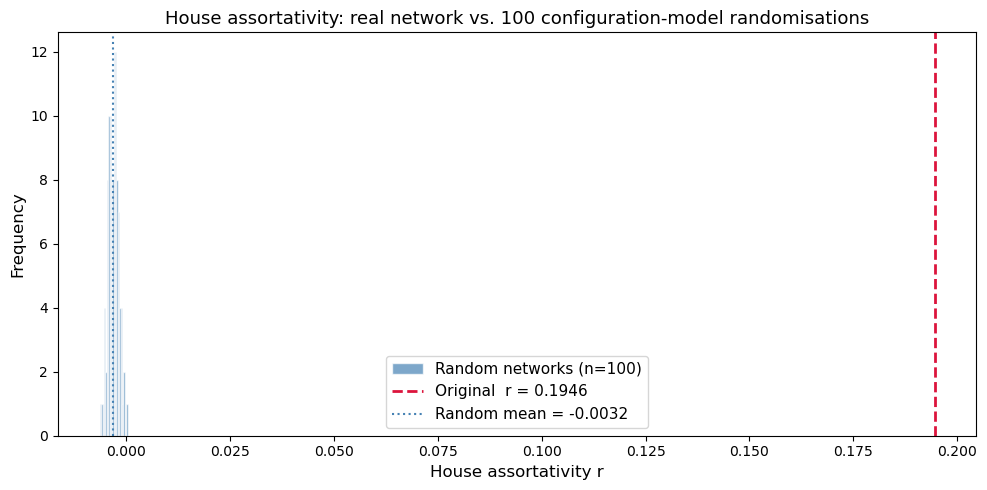

In [24]:
random.seed(42)
house_rs_random = []

for _ in tqdm(range(100), desc='Configuration model runs'):
    G_rand = configuration_model_swap(G)
    for node in G_rand.nodes():
        G_rand.nodes[node]['house'] = house_map.get(node)
    house_rs_random.append(house_assortativity(G_rand))

rand_mean = np.mean(house_rs_random)
rand_std  = np.std(house_rs_random)
z_score   = (original_house_r - rand_mean) / rand_std

print(f'Original r          = {original_house_r:.4f}')
print(f'Random mean ± std   = {rand_mean:.4f} ± {rand_std:.4f}')
print(f'Z-score             = {z_score:.2f}')

fig, ax = plt.subplots(figsize=(10, 5), facecolor=PLOT_BG)
style_axis(ax)
ax.hist(house_rs_random, bins=20, alpha=0.82, color=PLOT_BLUE,
        edgecolor=PLOT_BG, linewidth=0.8, label='Random networks (n=100)')
ax.axvline(original_house_r, color=PLOT_CRIMSON, lw=2.4, ls='--',
           label=f'Original  r = {original_house_r:.4f}')
ax.axvline(rand_mean, color=PLOT_GOLD, lw=1.8, ls=':',
           label=f'Random mean = {rand_mean:.4f}')
ax.set_xlabel('House assortativity r', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('House assortativity: real network vs. 100 configuration-model randomisations', fontsize=13)
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
from pathlib import Path
network_figures = Path('website/figures/network_analysis')
network_figures.mkdir(parents=True, exist_ok=True)
out_path = network_figures / 'house_assortativity_distribution.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved {out_path}')
plt.show()


### Degree assortativity

For the scalar (degree-based) version we use Newman's formula directly:

$$r = \frac{\frac{1}{M}\sum_{(i,j) \in E} j_i k_i - \left[\frac{1}{2M}\sum_{(i,j) \in E}(j_i + k_i)\right]^2}{\frac{1}{2M}\sum_{(i,j) \in E}(j_i^2 + k_i^2) - \left[\frac{1}{2M}\sum_{(i,j) \in E}(j_i + k_i)\right]^2}$$

where $j_i$ and $k_i$ are the degrees of the two endpoints of edge $i$, and $M$ is the total number of edges.

**What we found.** The real network is **disassortative by degree**: high-degree characters (Tyrion Lannister, Eddard Stark, Daenerys Targaryen) tend to connect to low-degree peripheral characters, not to each other. This is the hub-and-spoke topology you would expect from a feudal world: great lords accumulate many affiliations with minor bannermen, servants, and soldiers who have few connections of their own.

Comparing against the configuration model null shows the real $r$ is *more* negative than the randomised networks. The degree hierarchy is not just a consequence of the degree sequence but is an additional structural property. This tells us the network is organised in a way that actively places hubs at the periphery of each other, connected through intermediaries rather than directly. In narrative terms: the major players are rivals who interact indirectly, through the supporting cast.

In [25]:
def degree_assortativity(G):
    """Newman scalar formula for degree assortativity."""
    edges = list(G.edges())
    M     = len(edges)
    if M == 0:
        return float('nan')
    j = np.array([G.degree(u) for u, v in edges])
    k = np.array([G.degree(v) for u, v in edges])
    mu  = (j + k).sum() / (2 * M)
    num = (j * k).sum() / M - mu**2
    den = (j**2 + k**2).sum() / (2 * M) - mu**2
    return num / den if den != 0 else 0.0


original_degree_r = degree_assortativity(G)
print(f'Degree assortativity r = {original_degree_r:.4f}')
print(f'NetworkX check         r = {nx.degree_assortativity_coefficient(G):.4f}')


Degree assortativity r = -0.1216
NetworkX check         r = -0.1216


Configuration model runs: 100%|██████████| 100/100 [01:35<00:00,  1.05it/s]

Original r          = -0.1216
Random mean ± std   = -0.1144 ± 0.0039
Z-score             = -1.86


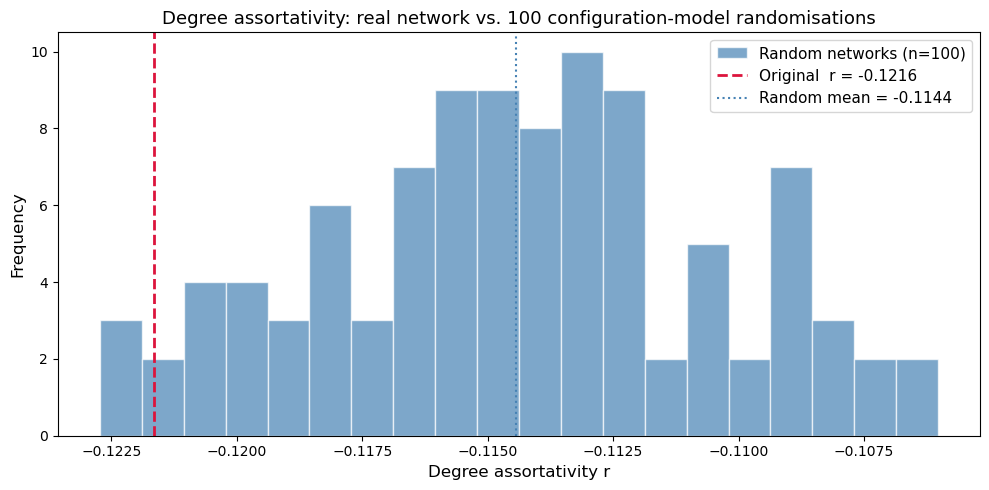

In [26]:
random.seed(42)
degree_rs_random = []

for _ in tqdm(range(100), desc='Configuration model runs'):
    degree_rs_random.append(degree_assortativity(configuration_model_swap(G)))

rand_mean_d = np.mean(degree_rs_random)
rand_std_d  = np.std(degree_rs_random)
z_score_d   = (original_degree_r - rand_mean_d) / rand_std_d

print(f'Original r          = {original_degree_r:.4f}')
print(f'Random mean ± std   = {rand_mean_d:.4f} ± {rand_std_d:.4f}')
print(f'Z-score             = {z_score_d:.2f}')

fig, ax = plt.subplots(figsize=(10, 5), facecolor=PLOT_BG)
style_axis(ax)
ax.hist(degree_rs_random, bins=20, alpha=0.82, color=PLOT_BLUE,
        edgecolor=PLOT_BG, linewidth=0.8, label='Random networks (n=100)')
ax.axvline(original_degree_r, color=PLOT_CRIMSON, lw=2.4, ls='--',
           label=f'Original  r = {original_degree_r:.4f}')
ax.axvline(rand_mean_d, color=PLOT_GOLD, lw=1.8, ls=':',
           label=f'Random mean = {rand_mean_d:.4f}')
ax.set_xlabel('Degree assortativity r', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Degree assortativity: real network vs. 100 configuration-model randomisations', fontsize=13)
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
from pathlib import Path
network_figures = Path('website/figures/network_analysis')
network_figures.mkdir(parents=True, exist_ok=True)
out_path = network_figures / 'degree_assortativity_distribution.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved {out_path}')
plt.show()


### Degree distribution

We compare the ASOIAF network's degree distribution against an Erdős–Rényi random graph with the same $N$ and connection probability $p = \langle k \rangle / (N-1)$, both plotted on log-log axes with logarithmic binning.

Logarithmic binning is necessary because linear bins would compress almost all mass into the first bar. The distribution spans several decades of degree and linear resolution destroys the tail structure. Geometric midpoints of the bin edges are used as the x-coordinates, and each bar is normalised by its bin width to give a proper probability density.

**What we found.** The random network clusters tightly around $\langle k \rangle$ with no meaningful tail. The Poisson distribution decays faster than exponential for $k > e\langle k \rangle$, so hubs are essentially impossible. The ASOIAF network is a completely different shape: a long tail of degree-1 and degree-2 minor characters extends far to the left of the mean, and a small number of major characters extend far to the right. Both tails are heavier than the Poisson prediction.

This is the same qualitative signature Barabási documents for the Internet, scientific collaboration networks, and protein interaction networks, real networks consistently have more low-degree nodes and more hubs than random networks of the same size and density. The ASOIAF network is no exception, and the divergence from the Poisson baseline is visible across nearly two orders of magnitude of degree.

The structural reason is straightforward: the story keeps returning to the same small set of POV characters (Tyrion, Jon, Daenerys, Cersei, Arya, ...), who accumulate affiliations with hundreds of supporting characters. Those supporting characters often appear in only one or two scenes and are connected to almost no one else. The narrative structure of epic fiction naturally produces the hub-and-spoke topology that is the hallmark of a heavy-tailed degree distribution.

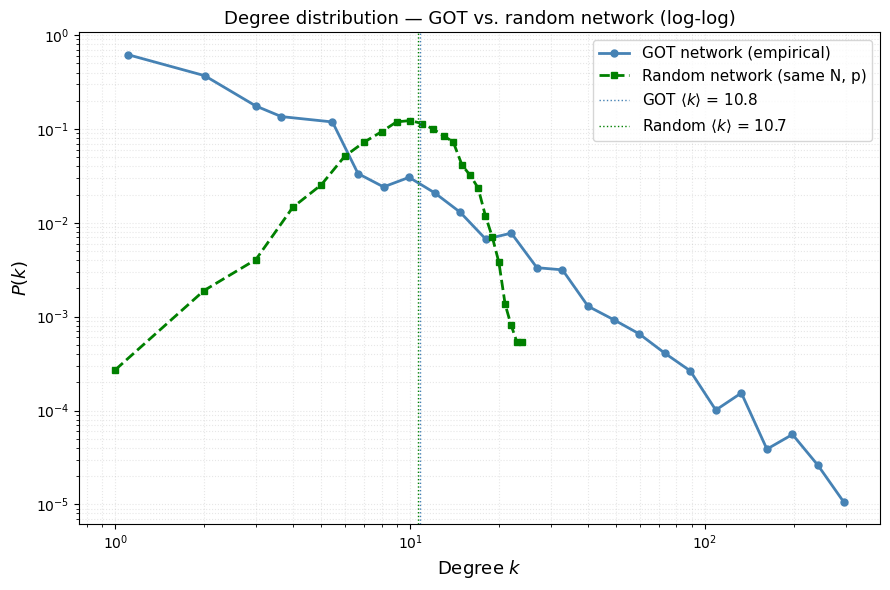

ASOIAF N=3690, <k>=10.8, max degree=326
Random N=3690, <k>=10.7, max degree=24
Top hub: Jaime Lannister


In [33]:
from math import factorial, exp

degrees = np.array([d for _, d in G.degree() if d > 0])
k_mean  = degrees.mean()
N       = G.number_of_nodes()
p_rand  = k_mean / (N - 1)

G_rand   = nx.erdos_renyi_graph(N, p_rand, seed=42)
deg_rand = np.array([d for _, d in G_rand.degree() if d > 0])
k_mean_r = deg_rand.mean()

def log_bin(degrees, n_bins=30):
    bins          = np.logspace(np.log10(degrees.min()), np.log10(degrees.max()), n_bins)
    counts, edges = np.histogram(degrees, bins=bins)
    centres       = np.sqrt(edges[:-1] * edges[1:])
    density       = counts / (counts.sum() * np.diff(edges))
    return centres[counts > 0], density[counts > 0]

def linear_bin(degrees):
    bins          = np.arange(degrees.min(), degrees.max() + 2) - 0.5  # one bin per integer degree
    counts, edges = np.histogram(degrees, bins=bins)
    centres       = (edges[:-1] + edges[1:]) / 2
    density       = counts / (counts.sum() * np.diff(edges))
    return centres[counts > 0], density[counts > 0]

x_got,  y_got  = log_bin(degrees)
x_rand, y_rand = linear_bin(deg_rand)

fig, ax = plt.subplots(figsize=(9, 6), facecolor=PLOT_BG)
style_axis(ax)
ax.plot(x_got,  y_got,  'o-',  color=PLOT_GOLD_BRIGHT, lw=2.2, ms=5.5, label='ASOIAF network (empirical)')
ax.plot(x_rand, y_rand, 's--', color=PLOT_BLUE,        lw=2.0, ms=5,   label='Random network (same N, p)')
ax.axvline(k_mean,   color=PLOT_CRIMSON, lw=1.6, ls=':', label=f'ASOIAF $\\langle k \\rangle$ = {k_mean:.1f}')
ax.axvline(k_mean_r, color=PLOT_BLUE,    lw=1.4, ls=':', label=f'Random $\\langle k \\rangle$ = {k_mean_r:.1f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree $k$', fontsize=13)
ax.set_ylabel('$P(k)$', fontsize=13)
ax.set_title('Degree distribution — ASOIAF vs. random network (log-log)', fontsize=13)
ax.legend(fontsize=11, frameon=True)
ax.grid(True, which='both', color=PLOT_GRID, alpha=0.45, ls=':', lw=0.8)
plt.tight_layout()
from pathlib import Path
network_figures = Path('website/figures/network_analysis')
network_figures.mkdir(parents=True, exist_ok=True)
out_path = network_figures / 'degree_distribution_loglog.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved {out_path}')
plt.show()

print(f'ASOIAF N={N}, <k>={k_mean:.1f}, max degree={degrees.max()}')
print(f'Random N={G_rand.number_of_nodes()}, <k>={k_mean_r:.1f}, max degree={deg_rand.max()}')
print(f'Top hub: {G.nodes[max(G.nodes, key=lambda n: G.degree(n))]["name"]}')
